Feature Engineering 

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [38]:
#It means creating, transforming, or selecting features (variables) from raw data so that models can learn patterns more effectively. Think of it as preparing the ingredients before cooking — the better the preparation, the better the final dish.

In [39]:
df=pd.read_csv('train.csv')

In [40]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


HANDLING MISSING VALUES

In [42]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

type-1 removing null values

In [24]:
# it is remove the total row in the table 
df.dropna().shape

(183, 12)

In [25]:
# drop the columns
df.dropna(axis=1).shape

(891, 9)

type-2 measures of Central Tendency  Implementation for normally distributed data 
- Mean  
- Median  
- Mode  

In [26]:
# now we have to know which measures of central tendence it is sutable to fill the null value 
#--Check the type of feature
#Numerical (continuous) → Mean or Median
#Categorical (discrete) → Mode

#--Look at the distribution
#If the feature is normally distributed (symmetric) → Use Mean
#If the feature is skewed (long tail) → Use Median (more robust to outliers)
#If the feature is categorical → Use Mode (most frequent value)

#--Check variance / spread
#Low variance → Mean imputation is safe (values are clustered).
#High variance / outliers present → Median is better (less distortion).


Original DataFrame with NaNs:
       Normal     Skewed    Uniform Categorical
0        NaN        NaN        NaN         nan
1  48.617357   5.023347  55.237338         Red
2  56.476885   2.553608  61.921350        Blue
3  65.230299   8.238172  54.326592         Red
4  47.658466  57.262422  27.571869         Red

Imputed DataFrame:
       Normal     Skewed    Uniform Categorical  Normal_imputed  \
0        NaN        NaN        NaN         nan       48.655104   
1  48.617357   5.023347  55.237338         Red       48.617357   
2  56.476885   2.553608  61.921350        Blue       56.476885   
3  65.230299   8.238172  54.326592         Red       65.230299   
4  47.658466  57.262422  27.571869         Red       47.658466   

   Skewed_imputed  Uniform_imputed Categorical_imputed  
0       15.085588        57.066644                 nan  
1        5.023347        55.237338                 Red  
2        2.553608        61.921350                Blue  
3        8.238172        54.326592       

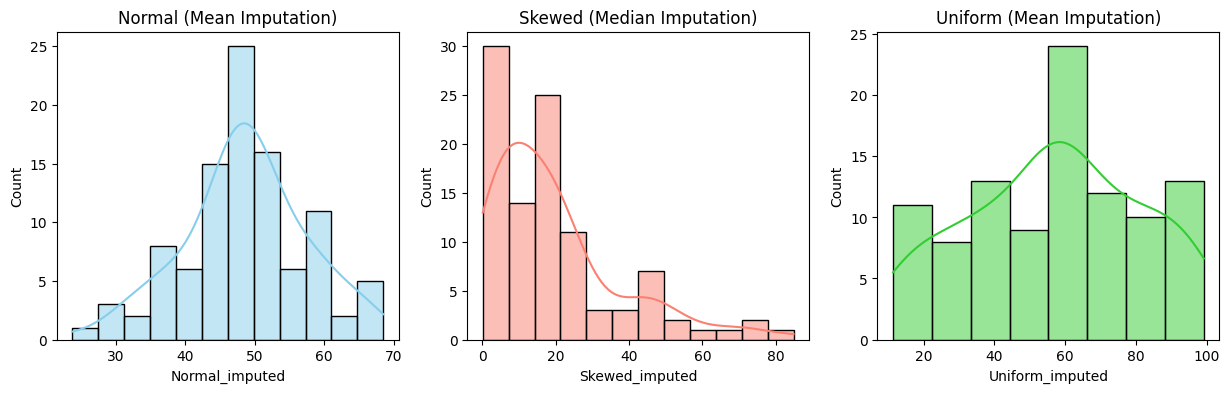

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Create synthetic datasets with missing values ---
np.random.seed(42)

# Normal distribution (symmetric)
normal_data = np.random.normal(loc=50, scale=10, size=100)
normal_data[::10] = np.nan   # insert NaNs

# Skewed distribution (exponential)
skewed_data = np.random.exponential(scale=20, size=100)
skewed_data[::15] = np.nan

# Uniform distribution
uniform_data = np.random.uniform(low=10, high=100, size=100)
uniform_data[::12] = np.nan

# Categorical distribution
categories = np.random.choice(['Red', 'Blue', 'Green'], size=100)
categories[::8] = np.nan

# --- 2. Put into a DataFrame ---
df = pd.DataFrame({
    'Normal': normal_data,
    'Skewed': skewed_data,
    'Uniform': uniform_data,
    'Categorical': categories
})

print("Original DataFrame with NaNs:\n", df.head())

# --- 3. Imputation based on distribution ---
df['Normal_imputed'] = df['Normal'].fillna(df['Normal'].mean())   # mean
df['Skewed_imputed'] = df['Skewed'].fillna(df['Skewed'].median()) # median
df['Uniform_imputed'] = df['Uniform'].fillna(df['Uniform'].mean()) # mean
df['Categorical_imputed'] = df['Categorical'].fillna(df['Categorical'].mode()[0]) # mode

print("\nImputed DataFrame:\n", df.head())

# --- 4. Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['Normal_imputed'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Normal (Mean Imputation)")

sns.histplot(df['Skewed_imputed'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title("Skewed (Median Imputation)")

sns.histplot(df['Uniform_imputed'], kde=True, ax=axes[2], color='limegreen')
axes[2].set_title("Uniform (Mean Imputation)")

plt.show()


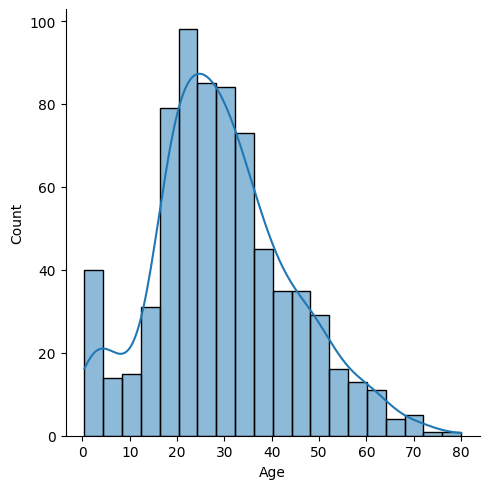

In [43]:
#First, we have to know how the data is distributed in the null column 
# For this, we have to calculate the distribution for the column using the seaborn 
#Distributions are fundamental tools in statistics because they describe how data is spread out and help us make sense of randomness and variation. Here’s why they matter:
sns.displot(df['Age'],kde=True)

In [49]:
# it is Normal distribution (symmetric) so we can use mean to fill the null value 
mean_age=np.mean(df['Age']).round()
mean_age


np.float64(30.0)

In [50]:
# we can fill the  mean vlaue for null value in the age 
df['Age'].fillna(mean_age,inplace=True)

C:\Users\VISHVA.S\AppData\Local\Temp\ipykernel_18780\1932027605.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(mean_age,inplace=True)


In [52]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [57]:
#both data type in ibject(catagorical) so we can use mode to fill the null values
print(df['Cabin'].dtype)
print(df['Embarked'].dtype)

object
object


In [66]:
mode_cabin=df['Cabin'].mode()
mode_Embarked=df['Embarked'].mode()
print(f"mode for cabin is:{mode_cabin}")
print(f"mode for embarked is:{mode_Embarked}")

mode for cabin is:0        B96 B98
1    C23 C25 C27
2             G6
Name: Cabin, dtype: object
mode for embarked is:0    S
Name: Embarked, dtype: object


In [71]:
df['Cabin'].fillna('B96 B98',inplace=True)
df['Embarked'].fillna('S',inplace=True)


In [72]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

type-4 random sampling imputation 

In [73]:
# In this, we can give any random value to replace the null value 
df['Age'].fillna(100)

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    30.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

Type-5 arbitrary imputation 

In [74]:
# In this, we give the arbitrary value (arbitrary values mean finding the value with mathematical inputation, which is suitable to fill the null value  in the feature)
df['Age'].fillna(28)

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    30.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

Handling The Imbalanced Dataset